# Day 1 - ?? ChemWorld ?????

??????????????????????????

?? notebook ????????????????????????????????????

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(1)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day01


## ????

????????????????????????????????????????????????????????????????

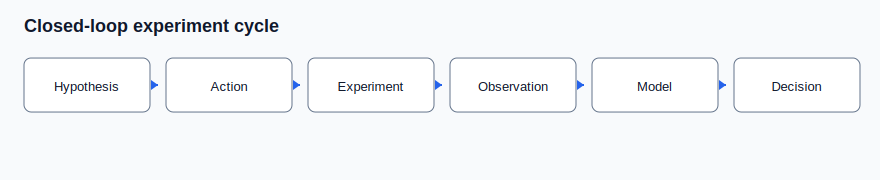

In [2]:
tu.display_tutorial_header(
    day=1,
    title='?? ChemWorld ?????',
    subtitle='??????????????????????????',
    focus=[
        'Gym ????',
        '???? API',
        'final assay ? reward ??',
        '????????',
    ],
    deliverables=[
        '????????',
        '?? trajectory ?',
        '?????????',
    ],
    project_link='?????????????????????????? benchmark trajectory?',
)
tu.display_course_map(1)
display(tu.workflow_svg())


In [3]:
tu.display_api_card()

In [4]:
tu.display_score_terms()

In [5]:
tu.display_student_checkpoint(
    1,
    [
        "one trajectory table or JSONL artifact",
        "one figure generated from your own run",
        "one chemical hypothesis",
        "one proposed next experiment",
        "one note on how GPT or another assistant was used",
    ],
)

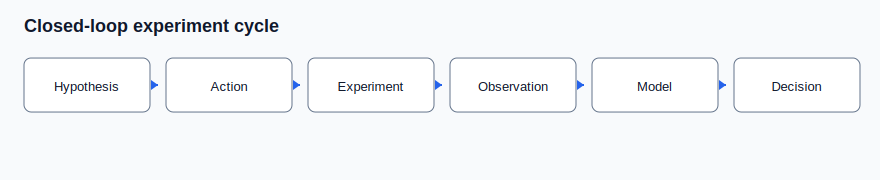

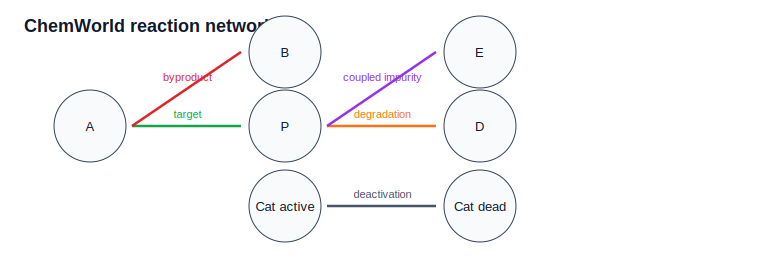

In [6]:
display(tu.workflow_svg())
display(tu.reaction_network_svg())

## 1.1 一个实验不是一个函数调用

`ChemWorld` 使用事件序列，而不是一次性黑箱函数。一个典型实验包括：

1. 加溶剂；
2. 加反应物；
3. 加催化剂；
4. 加热或等待，让 ODE transition kernel 演化隐藏状态；
5. 终止反应；
6. 用仪器测量。

注意：在测量之前，产率、选择性和转化率并不可见。


In [7]:
manual_events = [
    {"operation": "add_solvent", "volume_L": 0.030, "solvent": 2},
    {"operation": "add_reagent", "amount_mol": 0.010},
    {
        "operation": "add_catalyst",
        "catalyst_amount_mol": 0.00025,
        "catalyst": 1,
    },
    {
        "operation": "heat",
        "target_temperature_K": 388.0,
        "duration_s": 1500.0,
        "stirring_speed_rpm": 720.0,
    },
    {"operation": "measure", "instrument": "hplc"},
    {"operation": "wait", "duration_s": 600.0, "stirring_speed_rpm": 720.0},
    {"operation": "terminate"},
    {"operation": "measure", "instrument": "final_assay"},
]

trajectory = tu.run_events(manual_events, seed=7)
trajectory[
    [
        "step",
        "operation",
        "instrument",
        "reward",
        "leaderboard_score",
        "yield",
        "selectivity",
        "conversion",
        "cost",
        "risk",
        "observed_keys",
    ]
]

,step,operation,instrument,reward,leaderboard_score,yield,selectivity,conversion,cost,risk,observed_keys
0,1,add_solvent,None,0.0000,NaN,NaN,NaN,NaN,0.0384,0.0777,"cost, safety_risk, score"
1,2,add_reagent,None,0.0000,NaN,NaN,NaN,NaN,0.0684,0.0942,"cost, safety_risk, score"
2,3,add_catalyst,None,0.0000,NaN,NaN,NaN,NaN,0.2484,0.0942,"cost, safety_risk, score"
3,4,heat,None,0.0000,NaN,NaN,NaN,NaN,0.2609,0.1593,"cost, safety_risk, score"
4,5,measure,hplc,0.4079,NaN,0.6633,0.6687,NaN,0.3409,0.1593,"yield, selectivity, byproduct_signal, purity, ..."
5,6,wait,None,0.4198,NaN,0.6633,0.6687,NaN,0.3426,0.1104,"yield, selectivity, byproduct_signal, purity, ..."
6,7,terminate,None,0.4198,NaN,0.6633,0.6687,NaN,0.3426,0.1104,"yield, selectivity, byproduct_signal, purity, ..."
7,8,measure,final_assay,0.4405,0.4405,0.5891,0.5957,1.0,0.5026,0.1104,"yield, selectivity, conversion, byproduct_sign..."


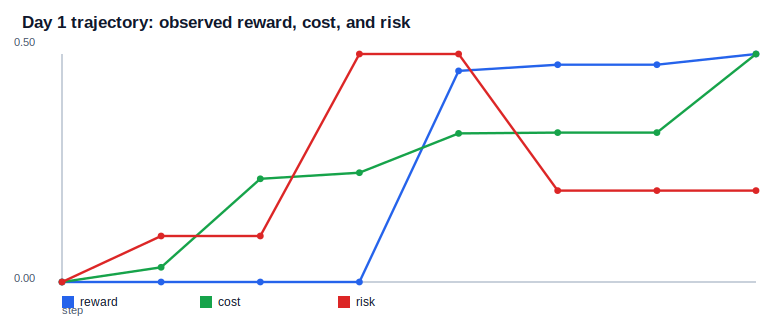

In [8]:
display(
    tu.line_svg(
        trajectory,
        x="step",
        ys=["reward", "cost", "risk"],
        title="Day 1 trajectory: observed reward, cost, and risk",
    )
)

## 当天练习

修改 `target_temperature_K`、`duration_s` 或 `solvent`，重新运行实验。
观察三个问题：

- HPLC 之后哪些字段仍然没有被测到？
- final assay 和 HPLC 的 `observed_keys` 有什么不同？
- 最高 reward 是否一定意味着最低风险？


## Exit Ticket

???????????????????????????

In [9]:
tu.display_reflection_box(["????????????????????????", "??????????????????????????????"])